In [1]:
import numpy as np
from matplotlib import pyplot as plt
from pathlib import Path

In [2]:
plt.rcParams.update({
    "text.usetex": True,    
    "font.size": 12
})
img_dir = Path('../results/img/')
img_dir.mkdir(exist_ok=True)

In [3]:
data_file = Path('../data/morlet/morlet_signal.npz')
with np.load(data_file, allow_pickle=True) as data:
    T = data['T']
    fs = data['fs']
    wave_len = data['wave_len']
    freq = data['freq']
    SNRdB = data['SNRdB']

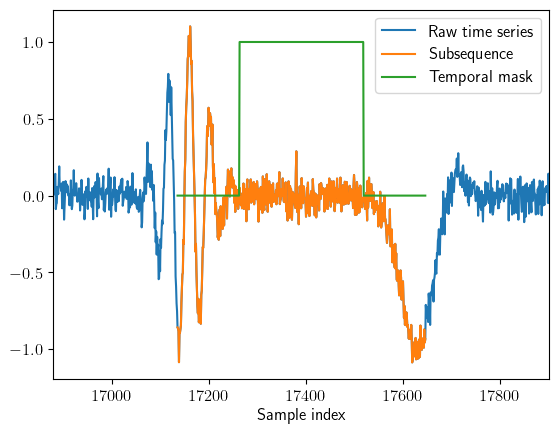

In [4]:
win_len = 512
i = 17135
i_half = i + win_len//2
idx1 = np.arange(i_half-win_len, i_half+win_len)
segment = T[idx1]
idx2 = np.arange(i, i+win_len)
subseq = T[idx2]
win = np.zeros_like(subseq)
win[win_len//4:3*win_len//4] = 1.0
plt.plot(idx1, segment)
plt.plot(idx2, subseq)
plt.plot(idx2, win)
plt.xlabel('Sample index')
plt.xlim([idx1[0], idx1[-1]])
plt.legend(['Raw time series', 'Subsequence', 'Temporal mask'])
fpath = img_dir.joinpath('temporal_masking_demo.pdf')
plt.savefig(fpath, bbox_inches='tight', pad_inches=0)

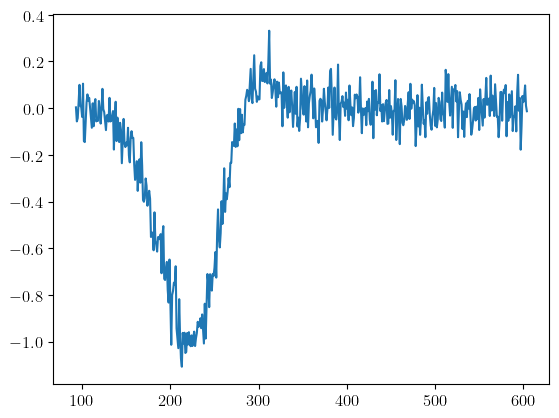

In [5]:
i = 93
idx = np.arange(i, i+win_len)
plt.plot(idx, T[idx])